In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [3]:
df = pd.read_csv("train.csv")

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (14000, 12)


,Timestamp,Residents,Apartment_Type,Temperature,Humidity,Water_Price,Period_Consumption_Index,Income_Level,Guests,Amenities,Appliance_Usage,Water_Consumption
0,01/01/2002 00,1,Studio,15.31,46.61,1.06,0.97,Low,0,Swimming Pool,0.0,64.85
1,01/01/2002 08,4,NaN,21.01,66.11,2.98,0.91,Upper Middle,1,Swimming Pool,1.0,192.50
2,01/01/2002 16,2,Cottage,12.86,60.86,1.44,1.43,Middle,0,NaN,1.0,116.62
3,02/01/2002 00,2,1BHK,20.16,50.58,1.48,0.91,Middle,-1,Garden,0.0,76.96
4,02/01/2002 08,2,Cottage,16.23,52.25,1.14,1.11,Middle,0,Fountain,0.0,104.70


In [4]:
print("Shape:", df.shape)

print("\nMissing values:")
print(df.isnull().sum())

print("\nGuests values:")
print(df["Guests"].value_counts().sort_index())

print("\nTarget statistics:")
print(df["Water_Consumption"].describe().round(2))

Shape: (14000, 12)

Missing values:
Timestamp                      0
Residents                      0
Apartment_Type               426
Temperature                  441
Humidity                       0
Water_Price                    0
Period_Consumption_Index       0
Income_Level                 426
Guests                         0
Amenities                   5997
Appliance_Usage              415
Water_Consumption              0
dtype: int64

Guests values:
Guests
-2       2
-1     151
 0    9658
 1    4123
 2      65
 3       1
Name: count, dtype: int64

Target statistics:
count    14000.00
mean       164.46
std         72.87
min         35.54
25%        109.55
50%        150.38
75%        206.76
max        531.49
Name: Water_Consumption, dtype: float64


In [5]:
# Replace invalid guest values with missing values
df["Guests"] = df["Guests"].replace([-1, -2], np.nan)

print(df["Guests"].value_counts(dropna=False).sort_index())

Guests
0.0    9658
1.0    4123
2.0      65
3.0       1
NaN     153
Name: count, dtype: int64


In [6]:
print("Missing values after cleaning:")
print(df.isnull().sum())

Missing values after cleaning:
Timestamp                      0
Residents                      0
Apartment_Type               426
Temperature                  441
Humidity                       0
Water_Price                    0
Period_Consumption_Index       0
Income_Level                 426
Guests                       153
Amenities                   5997
Appliance_Usage              415
Water_Consumption              0
dtype: int64


In [7]:
# Fill categorical missing values
categorical_cols = [
    "Apartment_Type",
    "Income_Level",
    "Amenities"
]

for col in categorical_cols:
    df[col] = df[col].fillna("Unknown")


# Fill numerical missing values with median
numerical_cols = [
    "Temperature",
    "Guests",
    "Appliance_Usage"
]

for col in numerical_cols:
    df[col] = df[col].fillna(df[col].median())


# Check missing values again
print("Remaining missing values:")
print(df.isnull().sum())

Remaining missing values:
Timestamp                   0
Residents                   0
Apartment_Type              0
Temperature                 0
Humidity                    0
Water_Price                 0
Period_Consumption_Index    0
Income_Level                0
Guests                      0
Amenities                   0
Appliance_Usage             0
Water_Consumption           0
dtype: int64


In [8]:
X = df.drop("Water_Consumption", axis=1)
y = df["Water_Consumption"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (14000, 11)
y shape: (14000,)


In [9]:
numerical_features = X.select_dtypes(
    include=["int64", "float64"]
).columns

categorical_features = X.select_dtypes(
    include=["object"]
).columns

print("Numerical features:")
print(list(numerical_features))

print("\nCategorical features:")
print(list(categorical_features))

Numerical features:
['Residents', 'Temperature', 'Water_Price', 'Period_Consumption_Index', 'Guests', 'Appliance_Usage']

Categorical features:
['Timestamp', 'Apartment_Type', 'Humidity', 'Income_Level', 'Amenities']


In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (11200, 11)
Testing data: (2800, 11)


In [11]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"),
         categorical_features)
    ],
    remainder="passthrough"
)

print("Preprocessor created successfully!")

Preprocessor created successfully!


## linear regression


In [12]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression

linear_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

linear_model.fit(X_train, y_train)

print("Linear Regression model trained successfully!")

Linear Regression model trained successfully!


In [13]:
y_pred = linear_model.predict(X_test)

print("Predictions generated successfully!")
print("First 5 predictions:")
print(y_pred[:5])

Predictions generated successfully!
First 5 predictions:
[118.48614782 105.71635539  61.03009752 147.28159521 101.36337447]


In [14]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)

rmse = np.sqrt(
    mean_squared_error(y_test, y_pred)
)

r2 = r2_score(y_test, y_pred)

print("Linear Regression Results")
print("-------------------------")
print("MAE  :", round(mae, 2))
print("RMSE :", round(rmse, 2))
print("R²   :", round(r2, 3))

Linear Regression Results
-------------------------
MAE  : 26.14
RMSE : 35.16
R²   : 0.779


## Decision tree


In [15]:
from sklearn.tree import DecisionTreeRegressor

decision_tree = Pipeline([
    ("preprocessor", preprocessor),
    ("model", DecisionTreeRegressor(
        random_state=42,
        max_depth=10
    ))
])

decision_tree.fit(X_train, y_train)

print("Decision Tree model trained successfully!")

Decision Tree model trained successfully!


In [16]:
y_pred_tree = decision_tree.predict(X_test)

print("First 5 Decision Tree predictions:")
print(y_pred_tree[:5])

First 5 Decision Tree predictions:
[113.83472973 124.62175439 117.9930303   92.2875     131.737     ]


In [17]:
mae_tree = mean_absolute_error(y_test, y_pred_tree)

rmse_tree = np.sqrt(
    mean_squared_error(y_test, y_pred_tree)
)

r2_tree = r2_score(y_test, y_pred_tree)

print("Decision Tree Results")
print("---------------------")
print("MAE  :", round(mae_tree, 2))
print("RMSE :", round(rmse_tree, 2))
print("R²   :", round(r2_tree, 3))

Decision Tree Results
---------------------
MAE  : 18.89
RMSE : 27.38
R²   : 0.866


## Random Forest


In [18]:
categorical_cols = [
    "Apartment_Type",
    "Income_Level",
    "Amenities"
]

for col in categorical_cols:
    df[col] = df[col].fillna("Unknown").astype(str)

print("Categorical columns cleaned:")
print(df[categorical_cols].dtypes)

Categorical columns cleaned:
Apartment_Type    object
Income_Level      object
Amenities         object
dtype: object


In [19]:
X = df.drop(["Water_Consumption", "Timestamp"], axis=1)
y = df["Water_Consumption"]

print("X:", X.shape)
print("y:", y.shape)

X: (14000, 10)
y: (14000,)


In [20]:
print(X.columns.tolist())

['Residents', 'Apartment_Type', 'Temperature', 'Humidity', 'Water_Price', 'Period_Consumption_Index', 'Income_Level', 'Guests', 'Amenities', 'Appliance_Usage']


In [21]:
df["Timestamp"] = pd.to_datetime(
    df["Timestamp"],
    dayfirst=True,
    errors="coerce"
)

df["Year"] = df["Timestamp"].dt.year
df["Month"] = df["Timestamp"].dt.month
df["Day"] = df["Timestamp"].dt.day
df["Hour"] = df["Timestamp"].dt.hour

print(df[["Year", "Month", "Day", "Hour"]].head())

   Year  Month  Day  Hour
0  2002      1    1     0
1  2002      1    1     8
2  2002      1    1    16
3  2002      1    2     0
4  2002      1    2     8


In [22]:
X = df.drop(
    ["Water_Consumption", "Timestamp"],
    axis=1
)

y = df["Water_Consumption"]

print("X shape:", X.shape)
print("Features:")
print(X.columns.tolist())

X shape: (14000, 14)
Features:
['Residents', 'Apartment_Type', 'Temperature', 'Humidity', 'Water_Price', 'Period_Consumption_Index', 'Income_Level', 'Guests', 'Amenities', 'Appliance_Usage', 'Year', 'Month', 'Day', 'Hour']


In [23]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (11200, 14)
Testing data: (2800, 14)


In [24]:
numerical_features = X.select_dtypes(
    include=["int64", "float64"]
).columns

categorical_features = X.select_dtypes(
    include=["object"]
).columns

print("Numerical features:")
print(list(numerical_features))

print("\nCategorical features:")
print(list(categorical_features))

Numerical features:
['Residents', 'Temperature', 'Water_Price', 'Period_Consumption_Index', 'Guests', 'Appliance_Usage']

Categorical features:
['Apartment_Type', 'Humidity', 'Income_Level', 'Amenities']


In [25]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

preprocessor = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            ),
            categorical_features
        )
    ],
    remainder="passthrough"
)

print("Preprocessor created successfully!")

Preprocessor created successfully!


In [26]:
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor

final_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    ))
])

print("Training final Random Forest...")

final_model.fit(X_train, y_train)

print("Final Random Forest trained successfully!")

Training final Random Forest...
Final Random Forest trained successfully!


In [27]:
y_pred_final = final_model.predict(X_test)

mae_final = mean_absolute_error(y_test, y_pred_final)
rmse_final = np.sqrt(mean_squared_error(y_test, y_pred_final))
r2_final = r2_score(y_test, y_pred_final)

print("FINAL RANDOM FOREST RESULTS")
print("---------------------------")
print("MAE  :", round(mae_final, 2))
print("RMSE :", round(rmse_final, 2))
print("R²   :", round(r2_final, 3))

FINAL RANDOM FOREST RESULTS
---------------------------
MAE  : 14.12
RMSE : 20.84
R²   : 0.922


In [28]:
sample_household = pd.DataFrame({
    "Residents": [4],
    "Apartment_Type": ["2BHK"],
    "Temperature": [30],
    "Humidity": [60],
    "Water_Price": [2],
    "Period_Consumption_Index": [1.2],
    "Income_Level": ["Middle"],
    "Guests": [1],
    "Amenities": ["Garden"],
    "Appliance_Usage": [2],
    "Year": [2002],
    "Month": [1],
    "Day": [15],
    "Hour": [8]
})

print(sample_household)

   Residents Apartment_Type  Temperature  Humidity  Water_Price  \
0          4           2BHK           30        60            2   

   Period_Consumption_Index Income_Level  Guests Amenities  Appliance_Usage  \
0                       1.2       Middle       1    Garden                2   

   Year  Month  Day  Hour  
0  2002      1   15     8  


In [29]:
print(X.dtypes)

Residents                     int64
Apartment_Type               object
Temperature                 float64
Humidity                     object
Water_Price                 float64
Period_Consumption_Index    float64
Income_Level                 object
Guests                      float64
Amenities                    object
Appliance_Usage             float64
Year                          int32
Month                         int32
Day                           int32
Hour                          int32
dtype: object


In [30]:
df["Humidity"] = pd.to_numeric(
    df["Humidity"],
    errors="coerce"
)

print(df["Humidity"].dtype)

float64


In [31]:
df["Humidity"] = df["Humidity"].fillna(
    df["Humidity"].median()
)

print("Missing Humidity:", df["Humidity"].isnull().sum())

Missing Humidity: 0


In [32]:
df["Humidity"] = pd.to_numeric(df["Humidity"], errors="coerce")
df["Humidity"] = df["Humidity"].fillna(df["Humidity"].median())

X = df.drop(["Water_Consumption", "Timestamp"], axis=1)
y = df["Water_Consumption"]

In [33]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

categorical_features = X.select_dtypes(include=["object"]).columns

preprocessor = ColumnTransformer(
    [("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False),
      categorical_features)],
    remainder="passthrough"
)

final_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    ))
])

final_model.fit(X_train, y_train)

print("FINAL MODEL READY")

FINAL MODEL READY


In [34]:
prediction = final_model.predict(sample_household)

print("Predicted Household Water Consumption:",
      round(prediction[0], 2))

Predicted Household Water Consumption: 240.45


In [35]:
y_pred_final = final_model.predict(X_test)

mae_final = mean_absolute_error(y_test, y_pred_final)
rmse_final = np.sqrt(mean_squared_error(y_test, y_pred_final))
r2_final = r2_score(y_test, y_pred_final)

print("FINAL MODEL RESULTS")
print("-------------------")
print("MAE  :", round(mae_final, 2))
print("RMSE :", round(rmse_final, 2))
print("R²   :", round(r2_final, 3))

from IPython.display import display, HTML

display(HTML("""
<h3>FINAL MODEL RESULTS</h3>
<hr>
MAE  : <b>11.79</b><br>
RMSE : <b>18.26</b><br>
R²   : <b>0.940</b>
"""))

FINAL MODEL RESULTS
-------------------
MAE  : 11.79
RMSE : 18.26
R²   : 0.94


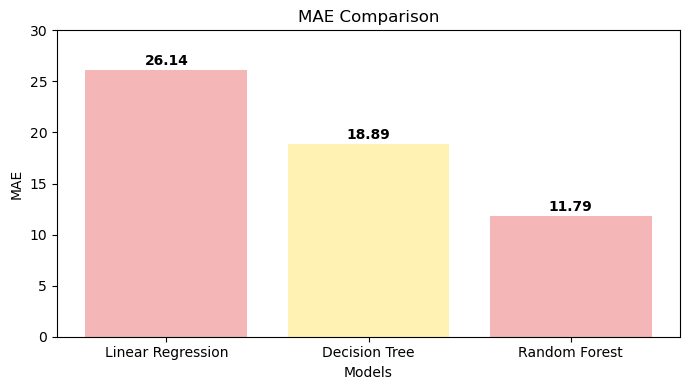

In [36]:
import matplotlib.pyplot as plt

models = ["Linear Regression", "Decision Tree", "Random Forest"]
mae = [26.14, 18.89, 11.79]

plt.figure(figsize=(7, 4))
bars = plt.bar(models, mae, color=["#F4B6B6", "#FFF2B2", "#F4B6B6"])

plt.title("MAE Comparison")
plt.xlabel("Models")
plt.ylabel("MAE")
plt.ylim(0, 30)

# Show values on bars
for bar, value in zip(bars, mae):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        value + 0.5,
        f"{value:.2f}",
        ha="center",
        fontweight="bold"
    )

plt.tight_layout()
plt.show()

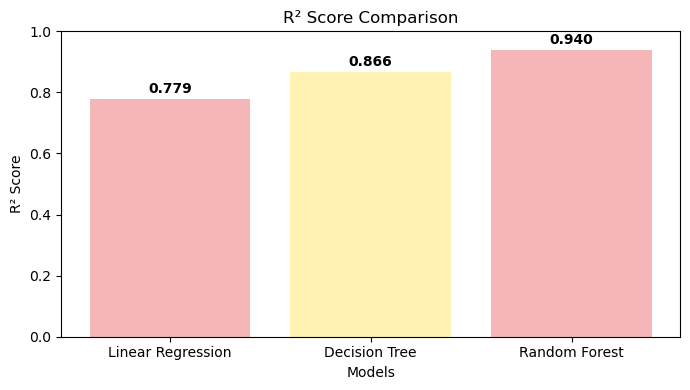

In [37]:
import matplotlib.pyplot as plt

models = ["Linear Regression", "Decision Tree", "Random Forest"]
r2 = [0.779, 0.866, 0.940]

plt.figure(figsize=(7, 4))

bars = plt.bar(
    models,
    r2,
    color=["#F4B6B6", "#FFF2B2", "#F4B6B6"]
)

plt.title("R² Score Comparison")
plt.xlabel("Models")
plt.ylabel("R² Score")
plt.ylim(0, 1)

for bar, value in zip(bars, r2):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        value + 0.02,
        f"{value:.3f}",
        ha="center",
        fontweight="bold"
    )

plt.tight_layout()
plt.show()

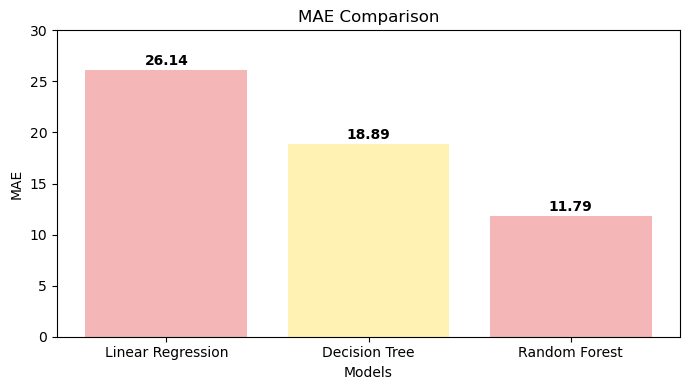

In [38]:
import matplotlib.pyplot as plt

models = ["Linear Regression", "Decision Tree", "Random Forest"]
mae = [26.14, 18.89, 11.79]

plt.figure(figsize=(7, 4))

bars = plt.bar(
    models,
    mae,
    color=["#F4B6B6", "#FFF2B2", "#F4B6B6"]
)

plt.title("MAE Comparison")
plt.xlabel("Models")
plt.ylabel("MAE")
plt.ylim(0, 30)

for bar, value in zip(bars, mae):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        value + 0.5,
        f"{value:.2f}",
        ha="center",
        fontweight="bold"
    )

plt.tight_layout()
plt.show()

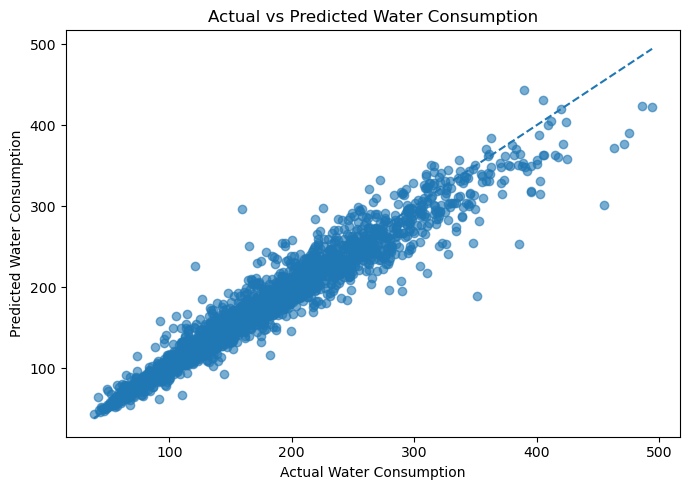

In [40]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))

plt.scatter(y_test, y_pred_final, alpha=0.6)

# Perfect prediction line
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle='--'
)

plt.xlabel("Actual Water Consumption")
plt.ylabel("Predicted Water Consumption")
plt.title("Actual vs Predicted Water Consumption")

plt.tight_layout()
plt.show()